# Tests of the sliding diffusion concept

The following with be experiements and tests of hyperparameter configurations, sometimes with numerical evalusaions, and prints for analasis. 

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from local_attention import transformer
from local_attention.rotary import SinusoidalEmbeddings, apply_rotary_pos_emb
import matplotlib.pyplot as plt
from typing import Union
from io import BytesIO
from PIL import Image
from moviepy import ImageSequenceClip
from datetime import datetime
from v1_sliding_diffusion import Diffusion

import wandb

In [2]:
wandb.login()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: anton-bertelsen (pefu-it-university-of-copenhagen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu")

self.time_step_stackings [(tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9932, 0.9798, 0.9599, 0.9339,
        0.9021, 0.8652, 0.8238, 0.7785, 0.7303, 0.6798, 0.6279, 0.5755, 0.5232,
        0.4718, 0.4220, 0.3742, 0.3291, 0.2869, 0.2479, 0.2123, 0.1801, 0.1514,
        0.1261, 0.1039, 0.0849, 0.0686, 0.0549, 0.0434, 0.0340, 0.0264, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000], device='cuda:0'), tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.

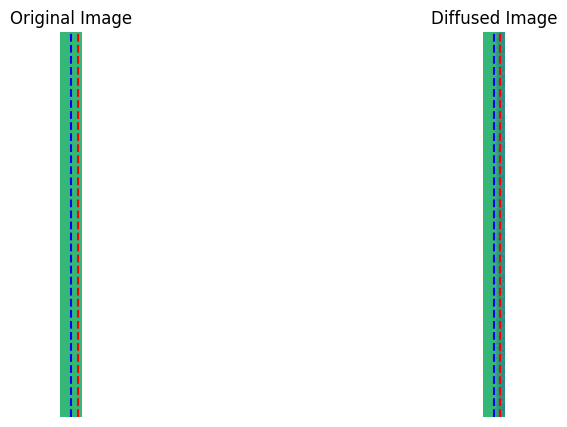

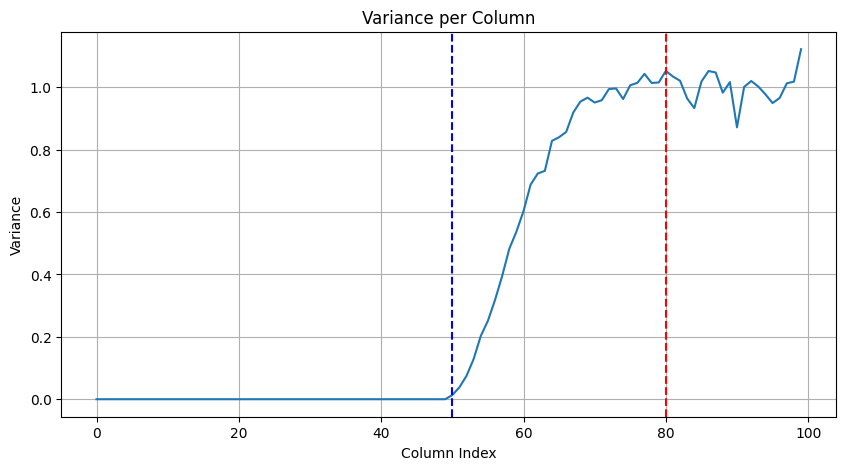

In [4]:
# Initialize the diffusion class
diffusion = Diffusion(
        num_of_pre_timestep_frames = 50, 
        num_of_timestep_frames = 30, 
        num_of_post_timestep_frames = 20, 
        noise_schedule = Diffusion.linear_schedule(0.0002, 0.40), 
        device = device 
    )

# Create a tensor that is all white so we can see the noising process removing details
image = torch.ones((177 * 10, 100))
image = image.to(device)

# Run the forward diffusion function
transformed_image = diffusion.forward(seqence_tensor = image)

# Draw both images next to each other in the python notebook
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image.cpu().numpy(), vmin=-3, vmax=3)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(transformed_image.cpu().numpy(), vmin=-3, vmax=3)
ax[1].set_title("Diffused Image")
ax[1].axis("off")

# Draw a vertical line at num_of_pre_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames
for a in ax:
    a.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
    a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

# Draw a vertical line at num_of_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames + diffusion.num_of_timestep_frames
for a in ax:
    a.axvline(x=line_x, color='red', linestyle='--', label='Timestep frames')
    a.set_xlim(0, transformed_image.shape[1])  # Set x-axis limits to match the image width

plt.show()

# Calculate the variance per frame (vertical slice)
variances = torch.var(transformed_image, dim=0)

# Plot the variance for each column
plt.figure(figsize=(10, 5))
plt.plot(variances.cpu().numpy())
plt.title("Variance per Column")
plt.xlabel("Column Index")
plt.ylabel("Variance")
plt.grid(True)

# Draw vertical lines at num_of_pre_timestep_frames and num_of_timestep_frames
line_x = diffusion.num_of_pre_timestep_frames
plt.axvline(x=line_x, color='blue', linestyle='--', label='Pre-timestep frames')
plt.axvline(x=line_x + diffusion.num_of_timestep_frames, color='red', linestyle='--', label='Timestep frames')


plt.show()

In [5]:
from v1_model import ContinuousMotionModel
from debugger import Debugger
from v1_traing_loop import train
from v1_sliding_diffusion import Diffusion

### Experiment 01

In [6]:
model = ContinuousMotionModel(
        deffsion_noise_scheduler=Diffusion(
            device=device,
            num_of_pre_timestep_frames=50,
            num_of_timestep_frames=100,
            num_of_post_timestep_frames=0,
            noise_schedule=Diffusion.linear_schedule(0.0002, 0.005)),
        number_of_styles = 17,
        n_gesture_length = 150,
        audio_features_per_frame = 804,
        pose_features_per_frame = 345,
        number_of_attention_heads = 8,
        debugger = Debugger(
            on=False, 
            keys_for_printing_while_running=["ALL"]
        ),
        device=device,
)

self.time_step_stackings [(tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.9999, 0.9997, 0.9996, 0.9994,
        0.9991, 0.9989, 0.9986, 0.9983, 0.9980, 0.9977, 0.9973, 0.9969, 0.9965,
        0.9961, 0.9956, 0.9951, 0.9946, 0.9941, 0.9936, 0.9930, 0.9924, 0.9918,
        0.9911, 0.9904, 0.9897, 0.9890, 0.9883, 0.9875, 0.9867, 0.9859, 0.9851,
        0.9842, 0.9834, 0.9825, 0.9815, 0.9806, 0.9796, 0.9786, 0.9776, 0.9766,
        0.9755, 0.9744, 0.9733, 0.9722, 0.9711, 0.9699, 0.9687, 0.9675, 0.9663,
        0.9650, 0.9637, 0.9624, 0.9611, 0.9598, 0.9584, 0.9570, 0.9556, 0.9542,
        0.952

In [7]:
num_of_timestap_stackings = 2
time_step_stacking_indexs = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] 
num_of_timestep_frames = 4

for time_step_stacking_index in time_step_stacking_indexs:
    timesteps_at_frames = [(t + 1) * num_of_timestap_stackings - (time_step_stacking_index % num_of_timestap_stackings) for t in range(num_of_timestep_frames)]
    print(timesteps_at_frames, " with size: ", len(timesteps_at_frames), " must be equal to: ", num_of_timestep_frames)  
    

[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4
[2, 4, 6, 8]  with size:  4  must be equal to:  4
[1, 3, 5, 7]  with size:  4  must be equal to:  4


In [8]:
# Load the model
# Load and fix the state dictionary
state_dict = torch.load('model_epoch_1_step_2000.pth')
new_state_dict = {}
for key, value in state_dict.items():
    # Remove the _orig_mod. prefix
    new_key = key.replace("_orig_mod.", "")
    new_state_dict[new_key] = value

# Then load the fixed state dict
model.load_state_dict(new_state_dict)
model.to(device)
model.eval()

ContinuousMotionModel(
  (time_step_mlp): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): SiLU()
    (2): Linear(in_features=32, out_features=64, bias=True)
  )
  (style_linear): Linear(in_features=17, out_features=64, bias=True)
  (audio_linear): Linear(in_features=804, out_features=64, bias=True)
  (noisy_gesture_linear): Linear(in_features=345, out_features=256, bias=True)
  (pre_local_attention_linear): Linear(in_features=384, out_features=256, bias=True)
  (multi_head_local_attention): LocalMHA(
    (to_qkv): Linear(in_features=256, out_features=768, bias=False)
    (attn_fn): LocalAttention(
      (dropout): Dropout(p=0.0, inplace=False)
      (rel_pos): SinusoidalEmbeddings()
    )
    (to_out): Linear(in_features=256, out_features=256, bias=False)
  )
  (relative_positional_embedding_funtion): SinusoidalEmbeddings()
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn)

In [ ]:
from torch.utils.data import DataLoader
from dataset.dataset import *

train(
    debug_run=True,
    experiment_collection_name="first_tests",
    model=model,
    device=device,
    training_loader=DataLoader(
            ConsolidatedRAMDataset(
                consolidated_file= "dataset/genea2023_dataset/trn/main-agent/consolidated.npz", # or "dataset/genea2023_dataset/trn/main-agent/training_windows_100k.npz"
                seq_length=150,
                seed_length=8,
                batch_size=512,
                epoch_length=5000
            ),
            batch_size = 1,
            num_workers = 0,
            pin_memory = True
        ),
    val_loader=None, 
    num_epochs=1000,
    lr=0.000005)

In [9]:
import os
import threading
import time
import socket
import asyncio
import json
import math
import random
from http.server import SimpleHTTPRequestHandler
from socketserver import TCPServer
import websockets
from IPython.display import display, HTML

%pip install nest_asyncio
import nest_asyncio
nest_asyncio.apply()

# Get or create a persistent state object
try:
    # Check if we're in IPython/Jupyter
    ipython = get_ipython()
    
    # Try to get existing state from user namespace
    if 'bvh_viewer_state' not in ipython.user_ns:
        ipython.user_ns['bvh_viewer_state'] = {
            'http_server_thread': None,
            'http_server_port': 8000,
            'websocket_thread': None,
            'websocket_port': None,
            'active_websocket_connections': set(),
            'visualization_initialized': False
        }
    
    # Get reference to state
    state = ipython.user_ns['bvh_viewer_state']
except:
    # Fallback if not in IPython - this will be recreated on each run
    state = {
        'http_server_thread': None,
        'http_server_port': 8000,
        'websocket_thread': None,
        'websocket_port': None,
        'active_websocket_connections': set(),
        'visualization_initialized': False
    }

class QuietHTTPRequestHandler(SimpleHTTPRequestHandler):
    def log_message(self, format, *args):
        pass  # Suppress logging

def find_free_port(start_port, end_port=None):
    """Find a free port in a given range"""
    if end_port is None:
        end_port = start_port + 100
        
    for port in range(start_port, end_port):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            try:
                s.bind(('localhost', port))
                return port
            except OSError:
                continue
    
    # If all ports in range are busy, try a random high port
    return random.randint(10000, 65000)

def check_port_in_use(port):
    """Check if a port is in use"""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(('localhost', port)) == 0

def start_http_server(port=8000):
    """Starts a simple HTTP server on the given port."""
    state['http_server_port'] = port
    
    # Allow socket reuse
    TCPServer.allow_reuse_address = True
    
    # Start a new server instance
    handler = QuietHTTPRequestHandler
    try:
        httpd = TCPServer(("", port), handler)
        print(f"HTTP Server running on http://localhost:{port}")
        httpd.serve_forever()
    except OSError as e:
        print(f"HTTP Server error: {e}")

# WebSocket handling
# To this:
async def websocket_handler(websocket):
    """Handle incoming WebSocket connections"""
    state['active_websocket_connections'].add(websocket)
    print(f"WebSocket client connected. Total connections: {len(state['active_websocket_connections'])}")
    try:
        await websocket.wait_closed()
    finally:
        state['active_websocket_connections'].remove(websocket)
        print(f"WebSocket client disconnected. Remaining: {len(state['active_websocket_connections'])}")

async def start_websocket_server_async(host="localhost", port=None):
    """Start the WebSocket server asynchronously"""
    if port is None:
        port = find_free_port(8700, 8800)
        
    try:
        server = await websockets.serve(websocket_handler, host, port)
        print(f"WebSocket server running on ws://{host}:{port}")
        state['websocket_port'] = port
        return server, port
    except OSError as e:
        print(f"WebSocket Server error: {e}")
        return None, None

def start_websocket_server(host="localhost", port=None):
    """Start the WebSocket server in a background thread"""
    # Create a new event loop for this thread
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    
    # Start the WebSocket server
    server, port = loop.run_until_complete(start_websocket_server_async(host, port))
    state['websocket_port'] = port
    
    # Run the event loop
    try:
        loop.run_forever()
    except Exception as e:
        print(f"WebSocket loop error: {e}")
    finally:
        loop.close()

# Function to send animation frames to connected clients
def send_frame(frame_data):
    """
    Send animation frame to all connected WebSocket clients
    
    Args:
        frame_data: Dictionary with animation data, should contain a "joints" list
        with position and rotation data for each joint
    """
    if not state['active_websocket_connections']:
        print("No WebSocket clients connected. Frame not sent.")
        return
    
    # Use asyncio to send the frame
    message = json.dumps(frame_data)
    
    async def send_to_all():
        await asyncio.gather(*[
            connection.send(message) 
            for connection in state['active_websocket_connections']
        ], return_exceptions=True)
    
    # Now we can safely use the event loop with nest_asyncio
    loop = asyncio.get_event_loop()
    loop.run_until_complete(send_to_all())

# Initialize servers and display visualization
def init_visualization():
    """Initialize the visualization if not already running"""
    # If already initialized, just return the current WebSocket port
    if state['visualization_initialized'] and state['websocket_port']:
        print(f"Visualization already running.")
        print(f"HTTP Server: http://localhost:{state['http_server_port']}")
        print(f"WebSocket Server: ws://localhost:{state['websocket_port']}")

        # Display the viewer
        html_file_path = f"http://localhost:{state['http_server_port']}/bvh_tests/bvh_visualisation/bvh_viewer_3.html?wsport={state['websocket_port']}"
        print(f"Viewer URL: {html_file_path}")
        iframe_html = f'<iframe src="{html_file_path}" width="512" height="512" frameborder="0"></iframe><br>'
        display(HTML(iframe_html))
        return state['websocket_port']
    
    # Check if HTTP port 8000 is in use but not by our server
    if check_port_in_use(8000) and (state['http_server_thread'] is None or not state['http_server_thread'].is_alive()):
        print("Port 8000 is in use by another application. Finding alternative port...")
        state['http_server_port'] = find_free_port(8001, 8100)
    else:
        state['http_server_port'] = 8000
    
    # Start HTTP server if not already running
    if state['http_server_thread'] is None or not state['http_server_thread'].is_alive():
        state['http_server_thread'] = threading.Thread(target=start_http_server, args=(state['http_server_port'],), daemon=True)
        state['http_server_thread'].start()
    
    # Start WebSocket server with a dynamically assigned port
    if state['websocket_thread'] is None or not state['websocket_thread'].is_alive():
        state['websocket_thread'] = threading.Thread(target=start_websocket_server, daemon=True)
        state['websocket_thread'].start()
    
    # Give servers time to start
    time.sleep(1)
    
    # Display the viewer
    html_file_path = f"http://localhost:{state['http_server_port']}/bvh_tests/bvh_visualisation/bvh_viewer_3.html?wsport={state['websocket_port']}"
    iframe_html = f'<iframe src="{html_file_path}" width="512" height="512" frameborder="0"></iframe><br>'
    display(HTML(iframe_html))
    
    print(f"Animation viewer ready!")
    print(f"HTTP Server: http://localhost:{state['http_server_port']}")
    print(f"WebSocket Server: ws://localhost:{state['websocket_port']}")
    print("Remember to click 'Start Streaming' button in the viewer.")
    
    state['visualization_initialized'] = True
    return state['websocket_port']

from utils.bvh_processing.bvh_converter3 import OffsetBVHParser

# Initialize visualization
init_visualization()

Note: you may need to restart the kernel to use updated packages.
Port 8000 is in use by another application. Finding alternative port...
HTTP Server running on http://localhost:8001
WebSocket server running on ws://localhost:8701


Animation viewer ready!
HTTP Server: http://localhost:8001
WebSocket Server: ws://localhost:8701
Remember to click 'Start Streaming' button in the viewer.


8701

WebSocket client connected. Total connections: 1


In [ ]:
from IPython.display import clear_output
from torch.amp import autocast
from dataset.dataset import *

# Now I want to test the autoregressive generation of the model
# model = torch.compile(model, backend="cudagraphs")

# Use no gradient calculation for inference
with torch.no_grad():
    # Load an example from the dataset
    dataset = SingleSampleAnimationDataset(
            folder = "dataset/genea2023_dataset/trn/main-agent/features",
            seq_length_in_frames = 150,
            seed_length_in_frames = 8,
            epoch_length = 5000,
            batch_size = 1
    )

    # Get a sample from the dataset
    gesture_sequence, seed_gesture, audio_features, main_agent_id_one_hot, full_audio_features, start_frame = [
        item.to(device) for item in next(iter(dataset))
    ]
    gesture_sequence = gesture_sequence * 0.1  # Scale the gesture sequence to a smaller range

    diffusion = model.deffsion_noise_scheduler

    # Apply noise to the gesture_sequence using the diffusion process
    noisy_gesture_sequence = diffusion.forward(
        seqence_tensor=gesture_sequence,
        stacking_step=0,
    )

    # Load std_pose and mean_pose from statistics.npz
    statistics = np.load("dataset/genea2023_dataset/trn/main-agent/statistics.npz")
    mean_pose = torch.tensor(statistics['mean_pose']).to(device)
    std_pose = torch.tensor(statistics['std_pose']).to(device)

    target_joints = ['body_world', 'b_root', 'b_r_foot', 'b_l_foot', 'b_l_upleg', 'b_l_leg', 'b_r_upleg', 'b_r_leg', 
                    'b_spine0', 'b_spine1', 'b_spine2', 'b_spine3', 'b_l_shoulder', 'b_l_arm', 'b_l_arm_twist', 
                    'b_l_forearm', 'b_l_wrist_twist', 'b_l_wrist', 'b_l_pinky1', 'b_l_pinky2', 'b_l_pinky3', 'b_l_ring1', 
                    'b_l_ring2', 'b_l_ring3', 'b_l_middle1', 'b_l_middle2', 'b_l_middle3', 'b_l_index1', 'b_l_index2', 
                    'b_l_index3', 'b_l_thumb0', 'b_l_thumb1', 'b_l_thumb2', 'b_l_thumb3', 'b_r_shoulder', 'b_r_arm', 
                    'b_r_arm_twist', 'b_r_forearm', 'b_r_wrist_twist', 'b_r_wrist', 'b_r_thumb0', 'b_r_thumb1', 
                    'b_r_thumb2', 'b_r_thumb3', 'b_r_pinky1', 'b_r_pinky2', 'b_r_pinky3', 'b_r_middle1', 'b_r_middle2', 
                    'b_r_middle3', 'b_r_ring1', 'b_r_ring2', 'b_r_ring3', 'b_r_index1', 'b_r_index2', 'b_r_index3', 
                    'b_neck0', 'b_head']

    bvh_template = "bvh_tests/bvh/template.bvh"

    # Load the BVH file and extract features
    parser = OffsetBVHParser(bvh_template, target_joints)
    # features = parser.extract_channels()

    import time
    start_time = time.time()
    iteration_counter = 0
    while True:
        debug_time_start = time.time()

        # Shift the gesture_sequence by one frame
        shifted_gesture_sequence = torch.roll(noisy_gesture_sequence, shifts=-1, dims=1)

        # print the duration of the shift operation in miliseconds
        debug_time_end = time.time()
        print(f"Time taken for shift operation: {((debug_time_end - debug_time_start) * 1000.0):.2f} milliseconds")
        

        # Replace the last frame with pure noise
        shifted_gesture_sequence[0,-1] = torch.randn_like(shifted_gesture_sequence[0,-1])

        # print the duration of the noise operation
        debug_time_start = time.time()
        print(f"Time taken for noise operation: {((debug_time_start - debug_time_end) * 1000.0):.2f} milliseconds")

        # Apply diffusion noise to the shifted_gesture_sequence
        shifted_gesture_sequence = diffusion.forward(seqence_tensor=shifted_gesture_sequence, stacking_step=0)

        # print the duration of the diffusion operation
        debug_time_end = time.time()
        print(f"Time taken for diffusion operation: {((debug_time_end - debug_time_start) * 1000.0):.2f} milliseconds")

        # The audio features also have to be shifted by one frame
        # I have the full audio features and the starting frame, so I extract the audio features for the current frame
        print("audio_features.shape: ", audio_features.shape)
        actual_audio_features = full_audio_features[start_frame + iteration_counter: start_frame + iteration_counter + shifted_gesture_sequence.shape[1], :].unsqueeze(0)

        # print the duration of the audio feature extraction operation
        debug_time_start = time.time()
        print(f"Time taken for audio feature extraction operation: {((debug_time_start - debug_time_end) * 1000.0):.2f} milliseconds")

        with autocast(device_type=device.type, dtype=torch.bfloat16):
            # Convert all inputs to same precision as autocast context

            # denoised_gesture_sequence = shifted_gesture_sequence
            denoised_gesture_sequence = model(
                current_time_step_stacking_level = 0,
                one_hot_style = main_agent_id_one_hot,
                audio_features = actual_audio_features, 
                noisy_gesture_sequence = shifted_gesture_sequence,
                condition_mask_probabilty = 0.0,
            )

            # print the duration of the model operation
            debug_time_end = time.time()
            print(f"Time taken for model operation: {((debug_time_end - debug_time_start) * 1000.0):.2f} milliseconds")

            # The above is essentially hole filling, so we replace the first 50 frames with the original shifted_gesture_sequence
            denoised_gesture_sequence[0, :50] = shifted_gesture_sequence[0, :50]

            # print the duration of the replacement operation
            debug_time_start = time.time()
            print(f"Time taken for replacement operation: {((debug_time_start - debug_time_end) * 1000.0):.2f} milliseconds")
        
        # Clear old output
        clear_output(wait=True)

        # Visualize the audio features and denoised gesture sequence stacked vertically
        # fig, axs = plt.subplots(2, 1, figsize=(5, 10))
        
        # # Audio features on top subplot
        # im1 = axs[0].imshow(actual_audio_features.squeeze(0).permute(1, 0).cpu().detach().numpy(), 
        #                     cmap='viridis', aspect='auto', vmin=-1, vmax=1)
        # axs[0].set_title("Audio Features")
        # axs[0].set_ylabel("Feature Index")
        # fig.colorbar(im1, ax=axs[0], label='Intensity')
        
        # # Denoised gesture sequence on bottom subplot
        # im2 = axs[1].imshow(shifted_gesture_sequence.squeeze(0).permute(1, 0).to(torch.float32).cpu().detach().numpy(), 
        #                     cmap='viridis', aspect='auto', vmin=-1, vmax=1)
        # axs[1].set_title("Denoised Gesture Sequence")
        # axs[1].set_xlabel("Frame Index")
        # axs[1].set_ylabel("Feature Index")
        
        # # Draw a vertical line at frame 50
        # line_x = 50
        # axs[1].axvline(x=line_x, color='red', linestyle='--', label='Pre-timestep frames')
        # axs[1].set_xlim(0, shifted_gesture_sequence.shape[1])  # Set x-axis limits to match the image width
        # axs[1].legend()
        
        # fig.colorbar(im2, ax=axs[1], label='Intensity')
        # plt.tight_layout()
        # plt.show()

        # print the duration of the visualization operation
        debug_time_end = time.time()
        print(f"Time taken for visualization operation: {((debug_time_end - debug_time_start) * 1000.0):.2f} milliseconds")

        # Undo the z-score normalization
        unnormalized_gesture_sequence = denoised_gesture_sequence * 10.0 * std_pose + mean_pose

        # print the duration of the unnormalization operation
        debug_time_start = time.time()
        print(f"Time taken for unnormalization operation: {((debug_time_start - debug_time_end) * 1000.0):.2f} milliseconds")

        frame = parser.features_to_websocket_format(unnormalized_gesture_sequence,50)
        send_frame(frame)

        # print the duration of the send frame operation
        debug_time_end = time.time()

        # Update the noisy_gesture_sequence for the next iteration
        noisy_gesture_sequence = denoised_gesture_sequence

        # Calculate the time taken for this iteration
        end_time = time.time()
        iteration_counter += 1
        elapsed_time = end_time - start_time

        # print(f"Time taken for iterations so far: {elapsed_time:.2f} seconds")
        # print(f"Iteration: {iteration_counter}")
        # print(f"iterations per second: {iteration_counter / elapsed_time:.2f}")
        # time.sleep(1.0/30.0)


Loaded statistics for normalization
dataset/genea2023_dataset/trn/main-agent/features\trn_2023_v0_256.npz


AttributeError: 'function' object has no attribute 'deffsion_noise_scheduler'

In [ ]:
model.debugger.get_available_keys()
model.debugger.print_from_key("ALL")
